In [35]:
# Standard library imports
import ssl
import os
import importlib

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

# Specialized ML imports
from transformers import get_scheduler

# Type hinting imports
from utils import set_seed

# Configure SSL for certain operations
ssl._create_default_https_context = ssl._create_unverified_context

from my_datasets import ObjectsDataset, CelebA, DSprites
import my_datasets
import importlib
import trainers

from models import VQELAgent
from trainers import train_self_play, train_mutual_play
from utils import load_dataset
from encoders import ProtoNetCNNEncoder, Dino

import torch.nn.functional as F
from torch.distributions import Categorical
from tqdm.auto import tqdm

from test_time import test_time_scaling
from test_time import test_time_sample_adaptation
from test_time import test_time_batch_adaptation
from test_time import test_time_dataset_adaptation

from utils import pairwise_cosine_similarity

from my_datasets import MNIST
import encoders
from my_datasets import PreSavedBatchDataset
import pandas as pd
from collections import defaultdict
from itertools import islice
from tqdm import tqdm

import utils
import models


In [36]:
importlib.reload(trainers)
importlib.reload(encoders)
importlib.reload(utils)
importlib.reload(models)
importlib.reload(my_datasets)

<module 'my_datasets' from '/home/mehdi_jmlkh/server2/VQTT/src/my_datasets.py'>

## Config

In [37]:
config_path = os.getenv('CONFIG', "config.py")

if config_path and os.path.exists(config_path):
    spec = importlib.util.spec_from_file_location("config", config_path)
    CFG = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(CFG)
else:
    print("No config file found.")

In [38]:
from dataclasses import dataclass
from typing import Optional, Any
from datetime import datetime

@dataclass
class VQExperimentConfig:
    """Configuration class for VQEL experiment."""
    
    refrential = CFG.refrential
    baseline = CFG.baseline
    dataset_tt = CFG.dataset_tt
    num_iterations = CFG.num_iterations
    learning_rate_tt = CFG.learning_rate_tt
    message_length_tt = CFG.message_length_tt
    test_time_mode = CFG.test_time_mode
    sampling_temperature_tt = CFG.sampling_temperature_tt
    best_of_n = CFG.best_of_n
    
    pretrained_checkpoint_a = CFG.pretrained_checkpoint_a
    pretrained_checkpoint_b = CFG.pretrained_checkpoint_b
    dialogued_checkpoint = CFG.dialogued_checkpoint
    sim: str = CFG.sim
    dataset: str = CFG.dataset
    num_test_classes = CFG.num_test_classes
        
    # Model hyperparameters
    batch_size: int = CFG.batch_size
    vocab_size: int = CFG.vocab_size
    representation_dim: int = CFG.representation_dim
    input_dim: int = 40
    message_length = CFG.message_length
    
    # VQ-specific hyperparameters
    ema_dead_code_factor = 2
    threshold_ema_dead_code: float = None  # batch_size / (vocab_size * ema_dead_code_factor)
    decay: float = CFG.decay
    commitment_weight: float = CFG.commitment_weight
    
    # Training hyperparameters
    learning_rate_phase1: float = CFG.learning_rate_phase1  # Learning rate for Phase 1 (Pretraining)
    learning_rate_phase2_a: float = CFG.learning_rate_phase2_a  # Learning rate for Phase 2 (Dialogue)
    learning_rate_phase2_b: float = CFG.learning_rate_phase2_b  # Learning rate for Phase 2 (Dialogue)

    weight_decay: float = 1e-5
    num_warmup_steps: int = 100
    
    # Pretraining parameters
    num_pretrain_epochs: int = CFG.num_pretrain_epochs
    
    # Dialogue training parameters
    num_dialogue_epochs: int = CFG.num_dialogue_epochs
    sampling_temperature: float = CFG.sampling_temperature
    entropy_regularization_factor: float = CFG.entropy_regularization_factor
    contrastive_loss_temperature: float = CFG.contrastive_loss_temperature
    agent_a_training_mode: str = CFG.agent_a_training_mode  # Options: 'frozen', 'reinforce_only', 'reinforce_with_preservation'
    freeze_codebook: bool = CFG.freeze_codebook  # Whether to freeze the codebook during text generation
    
    # Data split ratios
    train_split: float = 0.8
    val_split: float = 0.1
    test_split: float = 0.1
    
    # DataLoader parameters
    num_workers: int = 0
    drop_last: bool = True
    
    # Evaluation parameters
    number_of_candidates: int = CFG.number_of_candidates
    
    # System parameters
    seed: int = CFG.seed
    device: str = "auto"  # Will be set to 'cuda' or 'cpu' based on availability
    ckpt_dir: Optional[str] = None  # Will be generated from hyperparameters
    ckpt_dir_dialogue: Optional[str] = None  # Will be generated from hyperparameters
    
    # Logging parameters
    log_level: str = "INFO"
    tensorboard_log_dir: Optional[str] = None  # Will be generated from hyperparameters
    
    def __post_init__(self):
        """Post-initialization to set device and validate splits."""
        self.threshold_ema_dead_code: float =   self.batch_size / (self.vocab_size * self.ema_dead_code_factor)

        if self.device == "auto":
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
        # Validate that splits sum to 1.0
        total_split = self.train_split + self.val_split + self.test_split
        if abs(total_split - 1.0) > 1e-6:
            raise ValueError(f"Data splits must sum to 1.0, got {total_split}")
        
        # Validate agent training mode
        valid_modes = ['frozen', 'reinforce_only', 'reinforce_with_preservation']
        if self.agent_a_training_mode not in valid_modes:
            raise ValueError(f"agent_a_training_mode must be one of {valid_modes}, got {self.agent_a_training_mode}")
        
        # Validate datasets
        valid_datasets = ['objects', 'shape1', 'shape12', 'celeba', 'dsprites', 'mnist1', 'mnist2', 'imagenet', 'shape_unique_single_attribute', 'shape_unique_atleast_one_attribute']
        if self.dataset not in valid_datasets:
            raise ValueError(f"dataset must be one of {valid_datasets}, got {self.dataset}")
        
        # Generate checkpoint directories from hyperparameters
        if self.ckpt_dir is None or self.ckpt_dir_dialogue is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M")
            base_run_name = (
                f"{timestamp}_bs{self.batch_size}_vocab{self.vocab_size}_"
                f"repr{self.representation_dim}_msg_len{self.message_length_tt}_"
                f"lr1_{self.learning_rate_phase1}_lr2a_{self.learning_rate_phase2_a}_lr2b_{self.learning_rate_phase2_b}_"
                f"decay{self.decay}_mode{self.agent_a_training_mode}_"
                f"temp{self.sampling_temperature}_ent{self.entropy_regularization_factor}_"
                f"cand{self.number_of_candidates}_"
                f"contr{self.contrastive_loss_temperature}_seed{self.seed}"
            )
            
            if self.ckpt_dir is None:
                self.ckpt_dir = f"runs/{base_run_name}/checkpoints/pretraining"
            
            if self.ckpt_dir_dialogue is None:
                self.ckpt_dir_dialogue = f"runs/{base_run_name}/checkpoints/dialogue"
        
        # Generate tensorboard log directory from hyperparameters
        if self.tensorboard_log_dir is None:
            # Extract the base run name from ckpt_dir (remove checkpoints/ and /pretraining)
            base_path = self.ckpt_dir.replace('/pretraining', '').replace('/checkpoints', '')
            self.tensorboard_log_dir = f"{base_path}/tensorboard"
    
    def to_dict(self) -> dict[str, Any]:
        """Convert config to dictionary."""
        return {
            'baseline': self.baseline,
            'num_test_classes': self.num_test_classes,
            'dataset_tt': self.dataset_tt,
            'test_time_mode': self.test_time_mode,
            'sampling_temperature_tt': self.sampling_temperature_tt,
            'best_of_n': self.best_of_n,
            'num_iterations': self.num_iterations,
            'learning_rate_tt': self.learning_rate_tt,
            'message_length_tt': self.message_length_tt,
            'pretrained_checkpoint_a': self.pretrained_checkpoint_a,
            'pretrained_checkpoint_b': self.pretrained_checkpoint_b,
            'dialogued_checkpoint': self.dialogued_checkpoint,
            'sim': self.sim,
            'dataset': self.dataset,
            'batch_size': self.batch_size,
            'vocab_size': self.vocab_size,
            'representation_dim': self.representation_dim,
            'input_dim': self.input_dim,
            'message_length': f"{self.message_length}",
            'threshold_ema_dead_code': self.threshold_ema_dead_code,
            'decay': self.decay,
            'commitment_weight': self.commitment_weight,
            'learning_rate_phase1': self.learning_rate_phase1,
            'learning_rate_phase2_a': self.learning_rate_phase2_a,
            'learning_rate_phase2_b': self.learning_rate_phase2_b,
            'weight_decay': self.weight_decay,
            'num_warmup_steps': self.num_warmup_steps,
            'num_pretrain_epochs': self.num_pretrain_epochs,
            'num_dialogue_epochs': self.num_dialogue_epochs,
            'sampling_temperature': self.sampling_temperature,
            'entropy_regularization_factor': self.entropy_regularization_factor,
            'contrastive_loss_temperature': self.contrastive_loss_temperature,
            'agent_a_training_mode': self.agent_a_training_mode,
            'freeze_codebook': self.freeze_codebook,
            'train_split': self.train_split,
            'val_split': self.val_split,
            'test_split': self.test_split,
            'num_workers': self.num_workers,
            'drop_last': self.drop_last,
            'number_of_candidates': self.number_of_candidates,
            'seed': self.seed,
            'device': self.device,
            'ckpt_dir': self.ckpt_dir,
            'ckpt_dir_dialogue': self.ckpt_dir_dialogue,
            'log_level': self.log_level,
            'tensorboard_log_dir': self.tensorboard_log_dir
        }

# Create experiment configuration
config = VQExperimentConfig()
print(f"VQEL experiment configuration created: {config}")


VQEL experiment configuration created: VQExperimentConfig(sim='cosine', dataset='mnist1', batch_size=32, vocab_size=1000, representation_dim=32, input_dim=40, threshold_ema_dead_code=0.016, decay=0.99, commitment_weight=0.25, learning_rate_phase1=0.0001, learning_rate_phase2_a=0.0001, learning_rate_phase2_b=0.0001, weight_decay=1e-05, num_warmup_steps=100, num_pretrain_epochs=10, num_dialogue_epochs=10, sampling_temperature=1e-05, entropy_regularization_factor=1, contrastive_loss_temperature=0.01, agent_a_training_mode='frozen', freeze_codebook=True, train_split=0.8, val_split=0.1, test_split=0.1, num_workers=0, drop_last=True, number_of_candidates=32, seed=1, device='cuda', ckpt_dir='runs/20260207_0943_bs32_vocab1000_repr32_msg_len10_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05_ent1_cand32_contr0.01_seed1/checkpoints/pretraining', ckpt_dir_dialogue='runs/20260207_0943_bs32_vocab1000_repr32_msg_len10_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05

In [39]:
# Use config parameters instead of hardcoded values
device = torch.device(config.device)  # config.device is guaranteed to be set in __post_init__
train_batch_size = config.batch_size
representation_dim = config.representation_dim
vocab_size = config.vocab_size
message_length = config.message_length
threshold_ema_dead_code = config.threshold_ema_dead_code

In [40]:
from torch.utils.data import Dataset

class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels, indices):
        self.embeddings = embeddings[indices]
        self.labels = labels[indices]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


In [41]:
import random
from torch.utils.data import Sampler


class OneClassBatchSampler(Sampler):
    def __init__(self, class_to_indices, num_classes=50, shuffle=True):
        """
        Args:
            class_to_indices: dict[class_label] -> list of sample indices
            num_classes: number of classes to use (<= total classes)
            shuffle: shuffle order of batches
            seed: reproducibility
        """
        self.shuffle = shuffle

        all_classes = list(class_to_indices.keys())
        if num_classes > len(all_classes):
            raise ValueError("num_classes cannot exceed total number of classes")

        random.Random().shuffle(all_classes)
        selected_classes = all_classes[:num_classes]

        # Keep only selected classes
        self.class_batches = [class_to_indices[c] for c in selected_classes]

    def __iter__(self):
        if self.shuffle:
            random.Random(self.seed).shuffle(self.class_batches)
        for batch in self.class_batches:
            yield batch

    def __len__(self):
        return len(self.class_batches)
    
    
class DogClassBatchSampler(Sampler):
    def __init__(self, class_to_indices, num_classes=50, shuffle=True, batch_size=32):
        """
        Args:
            class_to_indices: dict[class_label] -> list of sample indices
            num_classes: number of classes to use (<= total classes)
            shuffle: shuffle order of batches
            seed: reproducibility
        """
        self.shuffle = shuffle
        self.batch_size = batch_size

        all_classes = sorted(list(class_to_indices.keys()))
        if num_classes > len(all_classes):
            raise ValueError("num_classes cannot exceed total number of classes")
        
        dog_classes = all_classes[151:269]
        random.shuffle(dog_classes)
        selected_classes =  dog_classes[:batch_size]
        # Keep only selected classes
        self.class_batches = [class_to_indices[c] for c in selected_classes]
        

    def __iter__(self):
        for i in range(32):
            yield [class_batch[i] for class_batch in self.class_batches]

    def __len__(self):
        return 32

In [42]:
# Initialize random seed for reproducibility
set_seed(config.seed)
batch_sampler = None
collate_fn = None
# Create dataset and split into train/validation/test sets
if config.dataset == 'objects':
    dataset = ObjectsDataset()
    train_dataset, val_dataset, test_dataset = random_split(dataset, [config.train_split, config.val_split, config.test_split])
    
    object_encoder_a = nn.Sequential(
        nn.Linear(config.input_dim, config.representation_dim)
    )
    object_encoder_b = nn.Sequential(
        nn.Linear(config.input_dim, config.representation_dim)
    )
    
elif config.dataset == 'shape1':
    train_dataset = load_dataset("/home/shared/data/shape/train")
    val_dataset = load_dataset("/home/shared/data/shape/val")
    test_dataset = load_dataset("/home/shared/data/shape/test/one_shape")
    if config.dataset_tt == 'shape1':
        test_time_dataset = load_dataset("/home/shared/data/shape/test/one_shape")
    else:
        test_time_dataset = load_dataset("/home/shared/data/shape/test/two_shape")
    
    # object_encoder_a = ProtoNetCNNEncoder()
    # object_encoder_b = ProtoNetCNNEncoder()
    # object_decoder_a = encoders.ProtoNetCNNDecoder(representation_dim=config.representation_dim)
    # object_decoder_b = encoders.ProtoNetCNNDecoder(representation_dim=config.representation_dim)
    
    object_encoder_a = encoders.SlotAttentionEncoder(resolution=(64, 64), num_slots=config.message_length[-1], num_iterations=10)
    object_encoder_b = encoders.SlotAttentionEncoder(resolution=(64, 64), num_slots=config.message_length[-1], num_iterations=10)
    object_decoder_a = encoders.SlotAttentionDecoder(resolution=(64, 64), num_slots=config.message_length[-1], num_iterations=10)
    object_decoder_b = encoders.SlotAttentionDecoder(resolution=(64, 64), num_slots=config.message_length[-1], num_iterations=10)
    
    
    
elif config.dataset == 'shape12':
    train_dataset = load_dataset("/home/shared/data/shape12/train")
    val_dataset = load_dataset("/home/shared/data/shape12/val")
    test_dataset = load_dataset("/home/shared/data/shape12/test")
        
    
    if config.dataset_tt == 'shape3':
        test_time_dataset = load_dataset("/home/shared/data/shape3/test")
    else:
        test_time_dataset = load_dataset("/home/shared/data/shape12/test")
    
    object_encoder_a = ProtoNetCNNEncoder()
    object_encoder_b = ProtoNetCNNEncoder()
elif config.dataset == 'celeba':
    dataset = CelebA(n=50000)
    train_dataset, val_dataset, test_dataset = random_split(dataset, [config.train_split, config.val_split, config.test_split])
    
    object_encoder_a = Dino()
    object_encoder_b = Dino()
    
elif config.dataset == 'dsprites':
    dataset = my_datasets.DSprites(n=20000)
    train_dataset, val_dataset, test_dataset = random_split(dataset, [config.train_split, config.val_split, config.test_split])
    
    object_encoder_a = ProtoNetCNNEncoder(in_channels=1)
    object_encoder_b = ProtoNetCNNEncoder(in_channels=1)
    
elif config.dataset == 'mnist1':
    dataset = MNIST('train', path='/home/shared/data/MNIST1')
    test_dataset = random_split(MNIST('test', path='/home/shared/data/MNIST1'), [2000, 8000])[0]
    
    train_dataset, val_dataset = random_split(dataset, [50000, 10000])
    
    # object_encoder_a = ProtoNetCNNEncoder(in_channels=1)
    # object_encoder_b = ProtoNetCNNEncoder(in_channels=1)
    # object_decoder_a = encoders.ProtoNetCNNDecoder(representation_dim=config.representation_dim, out_channels=1, sizes=[(1, 3), (3, 7), (7, 14), (14, 28), (28, 56)])
    # object_decoder_b = encoders.ProtoNetCNNDecoder(representation_dim=config.representation_dim, out_channels=1, sizes=[(1, 3), (3, 7), (7, 14), (14, 28), (28, 56)])
    
    object_encoder_a = encoders.SlotAttentionEncoder(num_slots=config.message_length[-1], num_iterations=3)
    object_encoder_b = encoders.SlotAttentionEncoder(num_slots=config.message_length[-1], num_iterations=3)
    object_decoder_a = encoders.SlotAttentionDecoder(num_slots=config.message_length[-1], num_iterations=3)
    object_decoder_b = encoders.SlotAttentionDecoder(num_slots=config.message_length[-1], num_iterations=3)
    

    if config.dataset_tt == 'mnist1':
        test_time_dataset = random_split(MNIST('test', path='/home/shared/data/MNIST1'), [2000, 8000])[0]
    else:
        test_time_dataset = random_split(MNIST('test', path='/home/shared/data/MNIST2'), [2000, 8000])[0]
elif config.dataset == 'imagenet':
    TEST_SAMPLES_PER_CLASS = 32
    
    data = torch.load(
        "/home/shared/data/imagenet_ResNet50/imagenet_embeddings.pt",
        map_location="cpu"
    )
    
    embeddings = data["embeddings"]   # (N, 2048)
    labels = data["labels"]           # (N,)
    
    df_emb = pd.DataFrame({
        "idx": range(len(labels)),
        "label": labels.numpy()
    })
    
    test_idx = (
        df_emb.groupby("label", group_keys=False)
              .apply(lambda x: x.sample(n=TEST_SAMPLES_PER_CLASS))
              ["idx"]
              .values
    )
    
    train_idx = df_emb.drop(test_idx).idx.values
    
    test_time_dataset  = EmbeddingDataset(embeddings, labels, test_idx)

    class_to_indices = defaultdict(list)

    for i, label in enumerate(test_time_dataset.labels.tolist()):
        class_to_indices[label].append(i)
    if config.dataset_tt == "imagenet_dog_breed":
        batch_sampler = DogClassBatchSampler(class_to_indices, shuffle=False, num_classes=config.num_test_classes, batch_size=config.number_of_candidates)
    else:
        batch_sampler = OneClassBatchSampler(class_to_indices, shuffle=False, num_classes=config.num_test_classes)


    dataset = EmbeddingDataset(embeddings, labels, train_idx)
    train_dataset, val_dataset, test_dataset = random_split(dataset, [0.8, 0.1, 0.1])

    object_encoder_a = encoders.IdentityEncoder()
    object_encoder_b = encoders.IdentityEncoder()
    
    if config.dataset_tt == "imagenet":
        test_time_dataset = test_dataset
        batch_sampler = None
elif config.dataset == 'shape_unique_single_attribute':
    train_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute/train.pt"))
    val_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute/validation.pt"))
    test_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute/test.pt"))

    object_encoder_a = ProtoNetCNNEncoder()
    object_encoder_b = ProtoNetCNNEncoder()
    
    if config.dataset_tt == 'shape_unique_single_attribute':
        test_time_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute/test.pt"))
    else:
        test_time_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_double_attribute/test.pt"))
    
    collate_fn = lambda x: x[0]
elif config.dataset == 'shape_unique_atleast_one_attribute':
    train_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_atleast_one_attribute/train.pt"))
    val_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_atleast_one_attribute/validation.pt"))
    test_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_atleast_one_attribute/test.pt"))

    object_encoder_a = ProtoNetCNNEncoder()
    object_encoder_b = ProtoNetCNNEncoder()
    
    if config.dataset_tt == 'shape_unique_atleast_one_attribute':
        test_time_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_atleast_one_attribute/test.pt"))
    else:
        test_time_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_double_attribute/test.pt"))
    
    collate_fn = lambda x: x[0]


# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=config.batch_size, 
    shuffle=True, 
    num_workers=config.num_workers, 
    drop_last=config.drop_last,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=config.batch_size, 
    shuffle=True, 
    num_workers=config.num_workers, 
    drop_last=config.drop_last,
    collate_fn=collate_fn
)

from models import BaselineAgent

if config.baseline:
    agent_a = BaselineAgent(
        input_dim=config.input_dim, 
        representation_dim=config.representation_dim, 
        vocab_size=config.vocab_size,
        object_encoder=object_encoder_a
    ).to(device)
    agent_b = BaselineAgent(
        input_dim=config.input_dim, 
        representation_dim=config.representation_dim, 
        vocab_size=config.vocab_size,
        object_encoder=object_encoder_b
    ).to(device)
else:
    agent_a = VQELAgent(
        input_dim=config.input_dim, 
        representation_dim=config.representation_dim, 
        threshold_ema_dead_code=config.threshold_ema_dead_code, 
        vocab_size=config.vocab_size,
        object_encoder=object_encoder_a,
        decay=config.decay, 
        commitment_weight=config.commitment_weight,
        orthogonal_reg_weight=0,
        use_cosine_sim = (config.sim == "cosine"),
        object_decoder=object_decoder_a
    ).to(device)

    agent_b = VQELAgent(
        input_dim=config.input_dim, 
        representation_dim=config.representation_dim, 
        threshold_ema_dead_code=config.threshold_ema_dead_code, 
        vocab_size=config.vocab_size,
        object_encoder=object_encoder_b,
        use_cosine_sim = (config.sim == "cosine"),
        object_decoder=object_decoder_b
    ).to(device)



In [43]:
import logging

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# Create tensorboard writer with auto-generated directory structure
writer = SummaryWriter(log_dir=config.tensorboard_log_dir)
logger.info(f"TensorBoard writer created at: {config.tensorboard_log_dir}")
logger.info(f"Checkpoint directory (Phase 1): {config.ckpt_dir}")
logger.info(f"Checkpoint directory (Phase 2): {config.ckpt_dir_dialogue}")


2026-02-07 09:43:04,891 [INFO] TensorBoard writer created at: runs/20260207_0943_bs32_vocab1000_repr32_msg_len10_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05_ent1_cand32_contr0.01_seed1/tensorboard
2026-02-07 09:43:04,891 [INFO] Checkpoint directory (Phase 1): runs/20260207_0943_bs32_vocab1000_repr32_msg_len10_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05_ent1_cand32_contr0.01_seed1/checkpoints/pretraining
2026-02-07 09:43:04,892 [INFO] Checkpoint directory (Phase 2): runs/20260207_0943_bs32_vocab1000_repr32_msg_len10_lr1_0.0001_lr2a_0.0001_lr2b_0.0001_decay0.99_modefrozen_temp1e-05_ent1_cand32_contr0.01_seed1/checkpoints/dialogue


In [44]:
if config.pretrained_checkpoint_b != None:
    agent_b.load_state_dict(torch.load(f'../experiments/{config.pretrained_checkpoint_b}/checkpoints/pretraining/best_model.pth', weights_only=True)['agent'])

if config.pretrained_checkpoint_a != None:
    agent_a.load_state_dict(torch.load(f'../experiments/{config.pretrained_checkpoint_a}/checkpoints/pretraining/best_model.pth', weights_only=True)['agent'])

if (config.pretrained_checkpoint_a == None) and (config.pretrained_checkpoint_b == None) and (not config.baseline):
    # # Configure optimizer with weight decay for regularization (Phase 1)
    optimizer = torch.optim.Adam(
        agent_a.parameters(), 
        lr=config.learning_rate_phase1, 
        weight_decay=config.weight_decay
    )
    # 
    # Set up learning rate scheduler with warmup (Phase 1)
    lr_scheduler = get_scheduler(
        'constant_with_warmup', 
        optimizer=optimizer, 
        num_warmup_steps=config.num_warmup_steps
    )
    # 
    # Pretrain agent A with specified hyperparameters
    trainers.train_self_play(
        agent_a, 
        train_loader, 
        val_loader, 
        optimizer, 
        lr_scheduler, 
        device, 
        config.num_pretrain_epochs, 
        length_message=config.message_length, 
        sampling_temperature=config.sampling_temperature, 
        entropy_factor=int(config.entropy_regularization_factor), 
        contrastive_loss_temperature=config.contrastive_loss_temperature, 
        ckpt_dir=config.ckpt_dir,
        refrential=config.refrential,
    )

Training Progress Epoch 0/10:   0%|          | 0/1562 [00:00<?, ?it/s]

RuntimeError: einsum(): subscript d has size 32 for operand 1 which does not broadcast with previously seen size 64

In [ ]:
from utils import evaluate_self_communicate

if config.baseline:
    self_play_acc_a = 0.0
else:
    self_play_acc_a = evaluate_self_communicate(
        agent_a, test_dataset, device, config.message_length[-1], number_of_candidates=config.number_of_candidates, collate_fn=collate_fn, refrential=config.refrential
    )
    

Evaluating image-text matching:   0%|          | 0/63 [00:00<?, ?it/s]

Reconstruction MSE: 0.009239


In [ ]:
if config.baseline:
    self_play_acc_b = 0.0
else:
    self_play_acc_b = evaluate_self_communicate(
        agent_b, test_dataset, device, config.message_length[-1], number_of_candidates=config.number_of_candidates, collate_fn=collate_fn, refrential=config.refrential
    )

Evaluating image-text matching:   0%|          | 0/63 [00:00<?, ?it/s]

Reconstruction MSE: 0.020796


# Play with Receiver 

In [ ]:
# Set up optimizer for both agents with appropriate learning rate and weight decay (Phase 2)
optimizer = torch.optim.Adam(
    [
        {
            "params": agent_a.parameters(),
            "lr": config.learning_rate_phase2_a,
            "weight_decay": config.weight_decay,
        },
        {
            "params": agent_b.parameters(),
            "lr": config.learning_rate_phase2_b,
            "weight_decay": config.weight_decay,
        }
    ]
)


# Calculate training steps and warmup schedule
num_training_steps = config.num_pretrain_epochs * len(train_loader)

# Initialize learning rate scheduler with warmup (Phase 2)
lr_scheduler = get_scheduler(
    'constant_with_warmup', 
    optimizer=optimizer, 
    num_warmup_steps=config.num_warmup_steps,
)

In [ ]:
importlib.reload(trainers)
importlib.reload(encoders)

<module 'encoders' from '/home/mehdi_jmlkh/server2/VQTT/src/encoders.py'>

In [ ]:
from trainers import train_agents_baseline_reinforce

if config.dialogued_checkpoint != None:
    agent_a.load_state_dict(torch.load(f'../experiments/{config.dialogued_checkpoint}/checkpoints/dialogue/best_model.pth', weights_only=True)['agent_a'])
    agent_b.load_state_dict(torch.load(f'../experiments/{config.dialogued_checkpoint}/checkpoints/dialogue/best_model.pth', weights_only=True)['agent_b'])
elif config.baseline:    
    best_val_acc, best_model_state = train_agents_baseline_reinforce(
        agent_a=agent_a,
        agent_b=agent_b,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        device=device,
        num_epochs=config.num_dialogue_epochs,
        message_length=config.message_length,
        sampling_temperature=config.sampling_temperature,
        entropy_regularization_factor=config.entropy_regularization_factor,
        contrastive_loss_temperature=config.contrastive_loss_temperature,
        ckpt_dir=config.ckpt_dir_dialogue,
        tensorboard_writer=writer,
        logger=logging.getLogger(__name__)
    )
    
    agent_a.load_state_dict(torch.load(f'./{config.ckpt_dir_dialogue}/best_model.pth', weights_only=True)['agent_a'])
    agent_b.load_state_dict(torch.load(f'./{config.ckpt_dir_dialogue}/best_model.pth', weights_only=True)['agent_b'])
else:
    best_model_state, best_val_acc = trainers.train_mutual_play(
        agent_a, 
        agent_b, 
        train_loader, 
        val_loader, 
        device, 
        config.message_length, 
        config.num_pretrain_epochs, 
        optimizer, 
        lr_scheduler,
        num_dialogue_epochs=config.num_dialogue_epochs,
        sampling_temperature=config.sampling_temperature,
        entropy_regularization_factor=config.entropy_regularization_factor,
        contrastive_loss_temperature=config.contrastive_loss_temperature,
        ckpt_dir=config.ckpt_dir_dialogue,
        agent_a_training_mode=config.agent_a_training_mode,
        freeze_codebook=config.freeze_codebook,
        tensorboard_writer=writer,
        refrential=config.refrential,
    )
    
    agent_a.load_state_dict(torch.load(f'./{config.ckpt_dir_dialogue}/best_model.pth', weights_only=True)['agent_a'])
    agent_b.load_state_dict(torch.load(f'./{config.ckpt_dir_dialogue}/best_model.pth', weights_only=True)['agent_b'])

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-07 09:07:53,447 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006358519..0.76555413].
2026-02-07 09:07:53,449 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0053184275..0.81315106].
2026-02-07 09:07:53,450 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0053184275..0.81315106].
2026-02-07 09:07:53,452 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008325728..0.7730206].


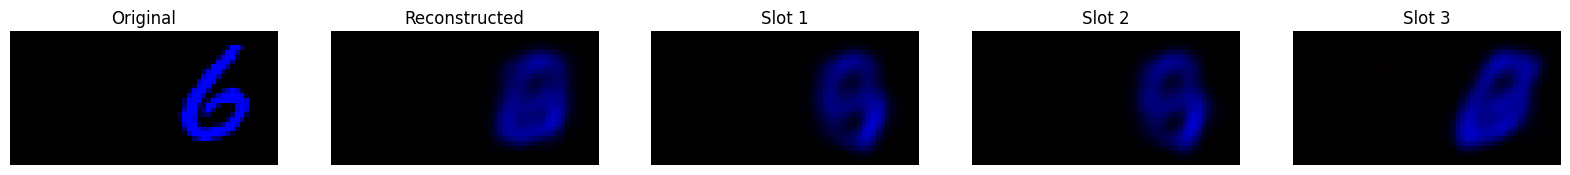

0.009145430865741912


In [ ]:
from utils import evaluate_cross_communicate

# Evaluate test accuracy
mutual_play_acc = evaluate_cross_communicate(agent_a, agent_b, test_dataset, device, config.message_length[-1], config.number_of_candidates, collate_fn=collate_fn, refrential=config.refrential)
print(mutual_play_acc)

# Test time Computation

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-07 09:07:57,741 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.005073369..0.89083266].
2026-02-07 09:07:57,743 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0071080048..0.69553405].
2026-02-07 09:07:57,744 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0050752386..0.80863595].
2026-02-07 09:07:57,746 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0047432063..0.9247967].
2026-02-07 09:07:57,747 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0059528193..0.92182904].
2026-02-07 09:07:57,748 [WARNING] Clipping input data to the valid range for imshow wit

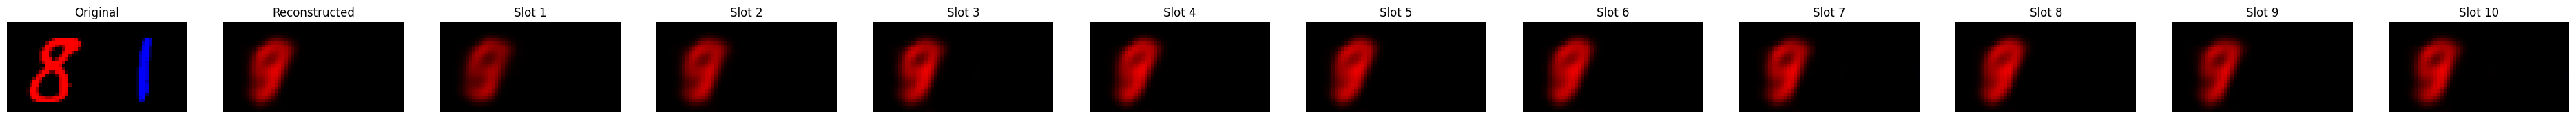

0.03371504738572098

In [ ]:
# Accuracy on OOD without test time training or adaptation
evaluate_cross_communicate(agent_a, agent_b, test_time_dataset, device, config.message_length_tt, config.number_of_candidates, batch_sampler=batch_sampler, collate_fn=collate_fn, refrential=config.refrential)

In [ ]:
if batch_sampler == None:
    test_loader = DataLoader(test_time_dataset, batch_size=config.number_of_candidates, shuffle=False, num_workers=0, collate_fn=collate_fn)
else:
    test_loader = DataLoader(test_time_dataset, batch_sampler=batch_sampler, collate_fn=collate_fn)

In [ ]:
import test_time
importlib.reload(test_time)

from test_time import test_time_scaling
from test_time import test_time_sample_adaptation
from test_time import test_time_batch_adaptation
from test_time import test_time_dataset_adaptation

Training Progress Epoch 0/10:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-07 09:08:08,924 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0407524..0.58020484].
2026-02-07 09:08:08,926 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02245602..0.71006536].
2026-02-07 09:08:08,927 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.051502407..0.86135685].
2026-02-07 09:08:08,928 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05232288..0.76970565].
2026-02-07 09:08:08,929 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.053404123..0.86957824].
2026-02-07 09:08:08,931 [WARNING] Clipping input data to the valid range for imshow with RGB d

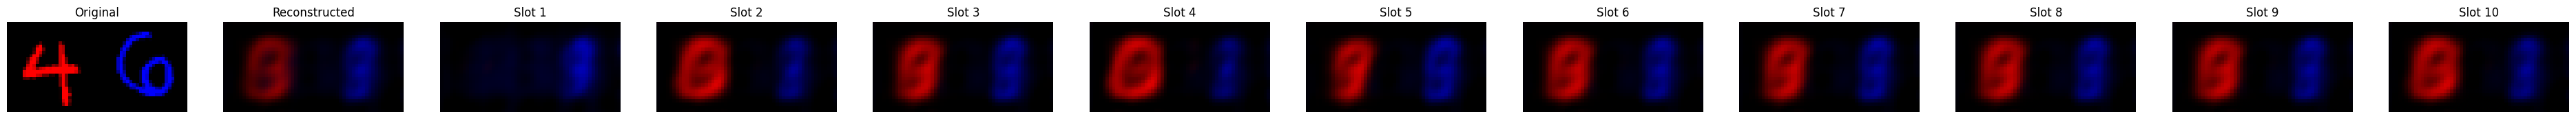

2026-02-07 09:08:09,480 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.043172702..0.62372935].
2026-02-07 09:08:09,482 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.052058652..0.76238567].
2026-02-07 09:08:09,483 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.052594244..0.870595].
2026-02-07 09:08:09,484 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05185458..0.7604403].
2026-02-07 09:08:09,486 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.052207246..0.768091].
2026-02-07 09:08:09,487 [WARNING] Clipping input data to the valid range for imshow with RGB dat

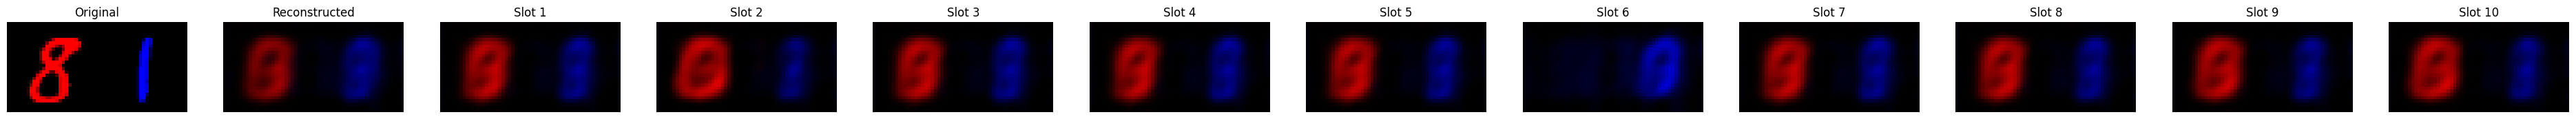

2026-02-07 09:08:09,744 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.046053197..0.7423482].
2026-02-07 09:08:09,746 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.053050667..0.8684947].
2026-02-07 09:08:09,747 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05554253..0.883605].
2026-02-07 09:08:09,749 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.055407718..0.8795766].
2026-02-07 09:08:09,750 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05122097..0.86021423].
2026-02-07 09:08:09,751 [WARNING] Clipping input data to the valid range for imshow with RGB data

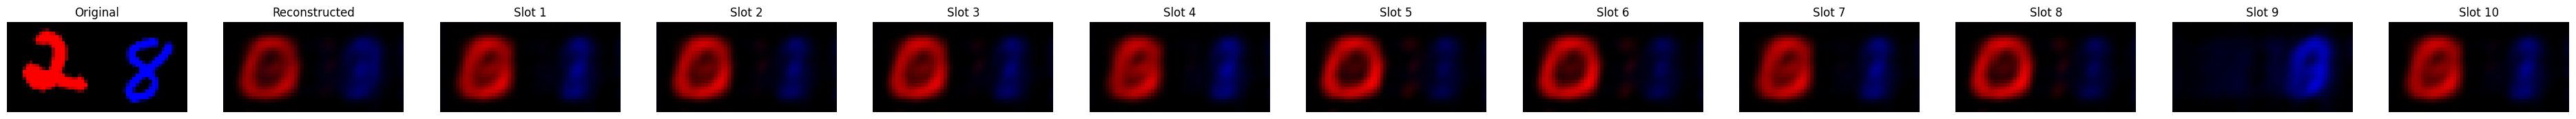

Training Progress Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 3/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 4/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 5/10:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-07 09:09:01,600 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014539884..0.62252796].
2026-02-07 09:09:01,602 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.019617006..0.77992976].
2026-02-07 09:09:01,603 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.020223022..0.8055892].
2026-02-07 09:09:01,605 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022212595..0.93417645].
2026-02-07 09:09:01,606 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.020505726..0.7824317].
2026-02-07 09:09:01,607 [WARNING] Clipping input data to the valid range for imshow with RGB

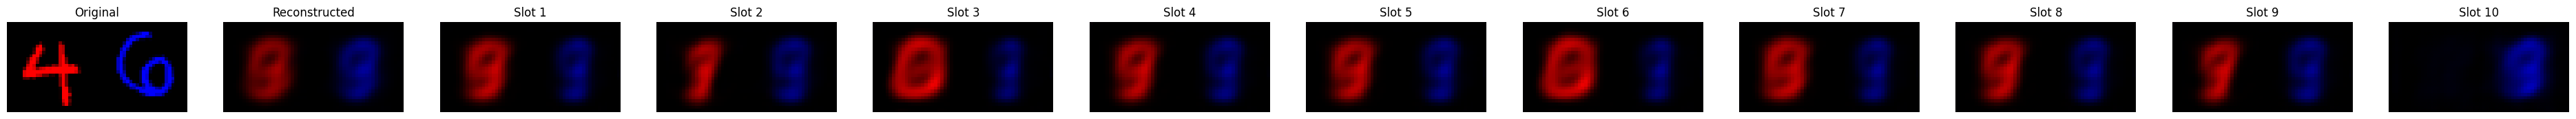

2026-02-07 09:09:01,856 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014574921..0.6342434].
2026-02-07 09:09:01,858 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01839234..0.8627831].
2026-02-07 09:09:01,859 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.020505726..0.7824317].
2026-02-07 09:09:01,861 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.019937694..0.89721966].
2026-02-07 09:09:01,862 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.018882021..0.76332927].
2026-02-07 09:09:01,864 [WARNING] Clipping input data to the valid range for imshow with RGB d

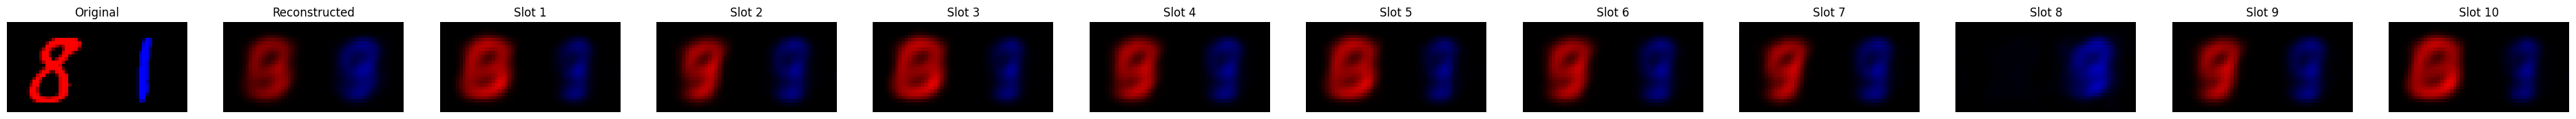

2026-02-07 09:09:02,115 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.016659232..0.8040692].
2026-02-07 09:09:02,117 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024470344..0.9603845].
2026-02-07 09:09:02,118 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.018882021..0.76332927].
2026-02-07 09:09:02,119 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028362319..1.0055922].
2026-02-07 09:09:02,120 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025462538..0.96648824].
2026-02-07 09:09:02,122 [WARNING] Clipping input data to the valid range for imshow with RGB 

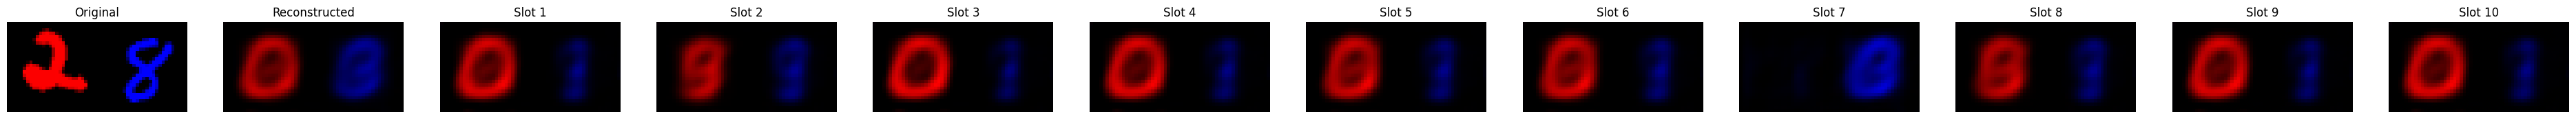

Training Progress Epoch 6/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 7/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 8/10:   0%|          | 0/63 [00:00<?, ?it/s]

Training Progress Epoch 9/10:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating image-text matching:   0%|          | 0/63 [00:00<?, ?it/s]

Reconstruction MSE: 0.023748


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

2026-02-07 09:09:49,517 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004451955..0.5639664].
2026-02-07 09:09:49,518 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.005858438..0.65789694].
2026-02-07 09:09:49,520 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.005858438..0.65789694].
2026-02-07 09:09:49,521 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006406512..0.09133707].
2026-02-07 09:09:49,522 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.005858438..0.65789694].
2026-02-07 09:09:49,524 [WARNING] Clipping input data to the valid range for imshow with RG

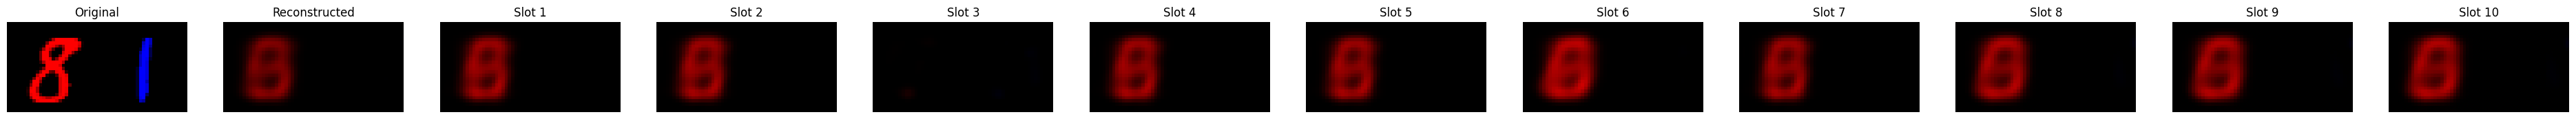

Final self play accuracy: 0.024
Final test accuracy with test-time training: 0.03


In [ ]:
if config.baseline:
    ttc_self_play_acc = 0.0
    ttc_mutual_acc = evaluate_cross_communicate(agent_a, agent_b, test_time_dataset, device, config.message_length_tt, config.number_of_candidates, batch_sampler=batch_sampler, collate_fn=collate_fn, refrential=config.refrential)

elif config.test_time_mode == 'dataset_adaptation':
    test_time_dataset_adaptation(agent_a, test_loader, message_length=config.message_length_tt,
        num_epochs=config.num_iterations, lr=config.learning_rate_tt, sampling_temperature=config.sampling_temperature_tt, refrential=config.refrential)

    ttc_self_play_acc = evaluate_self_communicate(agent_a, test_time_dataset, device, 
        config.message_length_tt, number_of_candidates=config.number_of_candidates, batch_sampler=batch_sampler, collate_fn=collate_fn, refrential=config.refrential)
    ttc_mutual_acc = evaluate_cross_communicate(agent_a, agent_b, test_time_dataset, device, 
        config.message_length_tt, config.number_of_candidates, batch_sampler=batch_sampler, collate_fn=collate_fn, refrential=config.refrential)

else:
    agent_b.eval()
    total_correct, total_ins = 0, 0
    total_correct_a = 0
    total_loss = 0.0
    total_loss_a = 0.0

    if config.test_time_mode == 'sample_adaptation':
        half_len = len(test_loader) // 2
        progress_bar = tqdm(
            islice(test_loader, half_len),
            total=half_len,
            desc="Testing time computation"
        )
    else:
        progress_bar = tqdm(test_loader, desc="Testing time computation")
        
    for iter_num, (imgs, labels) in enumerate(progress_bar):
        imgs = imgs.to(device)

        if config.test_time_mode == 'batch_adaptation':
            words, word_reprs = test_time_batch_adaptation(agent_a, imgs, message_length=config.message_length_tt,
                num_epochs=config.num_iterations, lr=config.learning_rate_tt, sampling_temperature=config.sampling_temperature_tt, refrential=config.refrential)
        else:
            ttc_words = []
            ttc_word_reprs = []
            for i in tqdm(range(len(imgs)), desc="Test-time training", leave=False):
                sample = imgs[i]

                if config.test_time_mode == 'scaling':
                    ttc_word, ttc_discretized = test_time_scaling(agent_a, sample, n=config.best_of_n, 
                        sampling_temperature=config.sampling_temperature_tt, message_length=config.message_length_tt)
                else:
                    ttc_word, ttc_discretized = test_time_sample_adaptation(agent_a, sample, num_iterations=config.num_iterations, 
                        lr=config.learning_rate_tt, sampling_temperature=config.sampling_temperature_tt, length_message=config.message_length_tt)

                ttc_words.append(ttc_word)
                ttc_word_reprs.append(ttc_discretized)
                
            # Stack all words into a batch
            words = torch.stack(ttc_words, dim=0).squeeze(1)
            word_reprs = torch.stack(ttc_word_reprs, dim=0).squeeze(1)

        # Evaluate with the listener (agent_b)
        listener_messages_repr = agent_b.forward_external_text_perception(words).squeeze(1)
        if config.refrential:
            listener_objects_repr = agent_b.forward_image_encoder(imgs)
            similarities_messages_to_objects = (F.normalize(listener_messages_repr, p=2, dim=1) @ F.normalize(listener_objects_repr, p=2, dim=1).T)
            batch_correct = (similarities_messages_to_objects.argmax(-1) == torch.arange(0, len(similarities_messages_to_objects)).to(device)).sum().item()
            total_correct += batch_correct
            total_ins += len(imgs)
        else:
            reconstructed_imgs = agent_b.forward_image_decoder(listener_messages_repr)
            criterion = nn.MSELoss()
            batch_loss = criterion(reconstructed_imgs, imgs).item()
            total_loss += batch_loss

        # Evaulate with the sender (agent_a)
        agent_a.eval()
        text_representations_a = agent_a.forward_text_perception(word_reprs)
        if config.refrential:
            image_representations_a = agent_a.forward_image_encoder(imgs)
            similarity_matrix = pairwise_cosine_similarity(text_representations_a, image_representations_a)
            predicted_matches = similarity_matrix.argmax(dim=1).cpu()
            total_correct_a += (predicted_matches == torch.arange(imgs.shape[0])).sum().item()

            # Show accuracy after each batch
            batch_accuracy = round(batch_correct/len(imgs), 3)
            cumulative_accuracy = round(total_correct/total_ins, 3)
            # print(f'Batch {iter_num+1} accuracy: {batch_accuracy}, Cumulative accuracy: {cumulative_accuracy}')
            progress_bar.set_postfix(batch_acc=batch_accuracy, cum_acc=cumulative_accuracy)
            progress_bar.refresh()
        else:
            reconstructed_imgs = agent_a.forward_image_decoder(text_representations_a)
            criterion = nn.MSELoss()
            total_loss_a += criterion(reconstructed_imgs, imgs).item()
            
            progress_bar.set_postfix(cum_loss=round(total_loss/(iter_num+1), 5), batch_loss=round(batch_loss, 5))
            progress_bar.refresh()


        agent_a.train()

    if config.refrential:
        ttc_self_play_acc = total_correct_a / total_ins
        ttc_mutual_acc = total_correct / total_ins
    else:
        ttc_self_play_acc = total_loss_a / len(test_loader)
        ttc_mutual_acc = total_loss / len(test_loader)


print('Final self play accuracy:', round(ttc_self_play_acc, 3))
print('Final test accuracy with test-time training:', round(ttc_mutual_acc, 3))

## Save

In [ ]:
import json
import os

result_dir = config.tensorboard_log_dir.replace("tensorboard", "results")
os.makedirs(result_dir, exist_ok=True)

results = {
    "VQEL": True,
    "metrics": {
        "self_play_accuracy_a": round(self_play_acc_a, 3),
        "self_play_accuracy_b": round(self_play_acc_b, 3),
        "mutual_play_accuracy": round(mutual_play_acc, 3),
        "test_time_self_play_accuracy": round(ttc_self_play_acc, 3),
        "test_time_training_accuracy": round(ttc_mutual_acc, 3)
    },
    "config": {k: v for k, v in config.to_dict().items()}
}

with open(os.path.join(result_dir, "report.json"), "w") as file:
    json.dump(results, file, indent=4)